In [16]:
import numpy as np
import pandas as pd
import matplotlib

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [2]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [3]:
# Get minimum value in each column with numerical values
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

`df.groupby(columns_to_group_by).summary_method()`

In [5]:
penguins['flipper_length_mm'].mean()

np.float64(200.91520467836258)

In [7]:
# Average flipper length per species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

In [8]:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length') # Rename series
                        .sort_values(ascending=False)
                        )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [9]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

In [10]:
# Number of NA observations
penguins['sex'].size - penguins['sex'].count()

np.int64(11)

In [ ]:
penguins.groupby('sex').size() # Leaves out the rows where the grouping column has NA values.

In [11]:
penguins.groupby('sex', dropna=False).size() # Keep the NA values as their own group

sex
female    165
male      168
NaN        11
dtype: int64

In [12]:
penguins.groupby(['island','year']).count() # Number of non NA values in each col for the island/year group

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [13]:
penguins.groupby(['island','year']).size() # Number of entries, regardless of NAs for each combo. Gives total number of penguins 

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

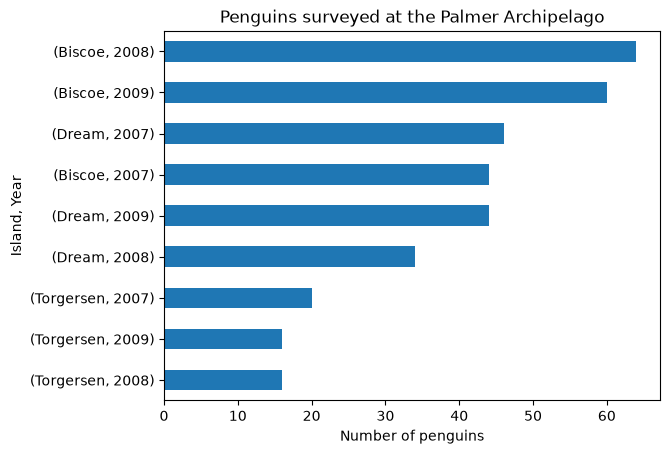

In [19]:
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )

In [25]:
# Maximum value of a penguin’s body mass by year and species
penguins.groupby(['species','year'])['body_mass_g'].max()

species    year
Adelie     2007    4675.0
           2008    4700.0
           2009    4775.0
Chinstrap  2007    4400.0
           2008    4800.0
           2009    4450.0
Gentoo     2007    6300.0
           2008    6000.0
           2009    6000.0
Name: body_mass_g, dtype: float64

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Species, Year'>

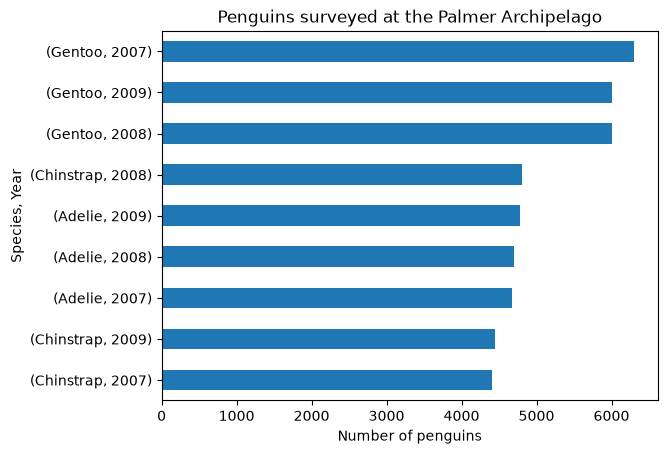

In [27]:
(penguins.groupby(['species','year'])['body_mass_g']
    .max()
    .sort_values()
    .plot(kind='barh',
            title = 'Penguins surveyed at the Palmer Archipelago',
            xlabel = 'Number of penguins',
            ylabel = 'Species, Year')

)